```{contents}
```
## Positional Encoding

### Why We Need Positional Encoding

Transformers have **no recurrence (RNN)** and **no convolution (CNN)**.
That means the model **doesn’t inherently know the order of tokens** in a sequence.

For example, the model sees these two sentences as identical:

> “I love cats.”
> “Cats love I.”

They have the same words, but **different order → different meaning**.

So, to give Transformers a sense of **sequence order**, we add **positional encodings** to input embeddings.

---

### Core Idea

Each token embedding is a vector (say, 512-dimensional).
We add another 512-dimensional vector — the **positional encoding** — that represents **the position (index)** of that token in the sequence.

This way:

$$
\text{Input to Encoder} = \text{Word Embedding} + \text{Positional Encoding}
$$

This addition injects **positional information** into the token embeddings.

---

### Mathematical Definition

In the original Transformer paper (*Vaswani et al., 2017*), positional encodings use **sinusoidal functions** of different frequencies:

For each position `pos` and dimension `i`:

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

Where:

* `pos` = position index (0, 1, 2, …)
* `i` = dimension index (0, 1, 2, …)
* `d_model` = embedding dimension (e.g., 512)

---

### Intuition Behind the Formula

The sine and cosine at different frequencies create **unique patterns** for each position:

* Low dimensions change **slowly** → capture **global** position.
* High dimensions change **rapidly** → capture **fine-grained** position.

Together, they form a **positional “signature”** that lets the model learn **relative** and **absolute** order.

### Why Sinusoids?

1. They’re **continuous and smooth** → easy to extrapolate beyond training length.
2. Relative positions can be derived via linear transformations (helpful for learning).

---

### Example (Small Scale)

Suppose $d_{model} = 4$ and we have positions 0–4.

| Position | PE(dim=0) | PE(dim=1) | PE(dim=2) | PE(dim=3) |
| -------- | --------- | --------- | --------- | --------- |
| 0        | 0.00      | 1.00      | 0.00      | 1.00      |
| 1        | 0.84      | 0.54      | 0.01      | 1.00      |
| 2        | 0.91      | -0.42     | 0.02      | 1.00      |
| 3        | 0.14      | -0.99     | 0.03      | 0.99      |
| 4        | -0.76     | -0.65     | 0.04      | 0.99      |

Each row = **unique positional pattern**.

---

### Implementation (PyTorch)


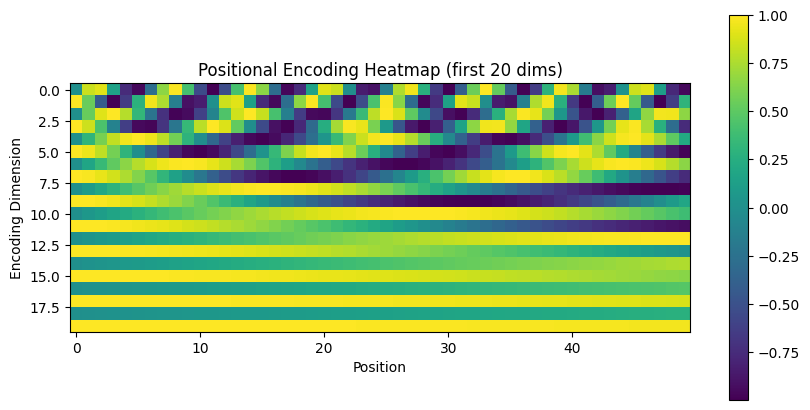

In [1]:
import torch
import math
import matplotlib.pyplot as plt

def positional_encoding(seq_len, d_model):
    PE = torch.zeros(seq_len, d_model)
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            angle = pos / (10000 ** ((2 * i)/d_model))
            PE[pos, i] = math.sin(angle)
            PE[pos, i+1] = math.cos(angle)
    return PE

PE = positional_encoding(seq_len=50, d_model=64)

plt.figure(figsize=(10,5))
plt.imshow(PE[:, :20].T, cmap='viridis')
plt.xlabel("Position")
plt.ylabel("Encoding Dimension")
plt.title("Positional Encoding Heatmap (first 20 dims)")
plt.colorbar()
plt.show()




This heatmap visualizes how sine and cosine values vary smoothly across positions and dimensions.

---

### How It’s Added to the Input

Each token’s input vector is:

$$
x_i = \text{Embedding}(token_i) + \text{PE}(pos_i)
$$

For example:

```
Input tokens: [“I”, “love”, “cats”]
Embeddings:  [e1, e2, e3]
PE:          [p1, p2, p3]
Final input: [e1+p1, e2+p2, e3+p3]
```

The model now knows:

* Which token is which (via embedding)
* Where each token is (via PE)

---

### Learned Positional Encodings (Alternative)

Some modern models (e.g., **BERT**) use **learned** positional encodings instead of fixed sinusoids.

### Comparison

| Type           | Description          | Pros                                   | Cons                                      |
| -------------- | -------------------- | -------------------------------------- | ----------------------------------------- |
| **Sinusoidal** | Fixed, deterministic | Generalizes to unseen lengths          | Static, cannot adapt                      |
| **Learned**    | Trainable embeddings | More flexible, learned during training | May not generalize beyond training length |

---

### Why Positional Encoding Works

It gives the model:

* A **unique pattern** per position
* A **relative sense** of distance (because sin/cos differences encode distance)
* Ability to **combine meaning + position** in the same vector space

For instance, the model can learn:

> "In English, adjectives often appear **before** nouns."

It learns this **only** because the order is encoded numerically.

---

**Summary Table**

| Concept      | Description                                                               |
| ------------ | ------------------------------------------------------------------------- |
| **Purpose**  | Inject order information into Transformer inputs                          |
| **Type**     | Sinusoidal (fixed) or learned                                             |
| **Formula**  | (PE_{(pos,2i)} = \sin(pos / 10000^{2i/d})), (PE_{(pos,2i+1)} = \cos(...)) |
| **Added To** | Token embeddings before encoder input                                     |
| **Effect**   | Allows model to differentiate order and distance of tokens                |

---

**Intuition Recap**

> Positional encoding is like giving each word its **GPS coordinates** in the sentence.
> The Transformer doesn’t “move” left-to-right — it sees all tokens at once — so it needs those coordinates to know **where each word is** and **how far apart they are**.
